# 2주차 (b) — 전처리 파이프라인 + Naive·ARIMA 베이스라인

> 계획서 v5.1 §9 2주차 작업 — 산출물 3건(02) 외 나머지 5개 작업

## 본 노트북의 목표

| 작업 | 계획서 근거 | 대응 절 |
|------|------------|--------|
| 1. 전처리 파이프라인 (정책 변수 t-1, Robust Scaler train-fit) | §4.3, CL-02·CL-05 | §3, §7 |
| 2. Lag/Rolling Feature (`shift(k)`, `.rolling().mean().shift(1)`) | §4.3, CL-03 | §5, §6 |
| 3. Naive 베이스라인 (`Δŷ=0`) — RMSE 측정 | §5.1, §9 검증 포인트 | §8 |
| 4. ARIMA 베이스라인 (자기상관 학습 능력) | §5.1 | §9 |
| 5. 누수 코드 리뷰 (체크리스트 7개 자동 검증) | `data_leakage_checklist.md` | §10 |
| 6. 리포트 템플릿 골격 | §8 산출물 | §11 |

## 입력 / 출력

**입력**: `data/processed/features_v1_candidate.csv` (1주차 freeze 9 + 타겟)

**출력**:
- `data/processed/features_with_lags_v1.csv` — Lag/Rolling 적용 + scaled
- `data/processed/baseline_results.csv` — Naive·ARIMA RMSE/MAE/방향성
- `reports/figures/w2_04_baseline_compare.png`
- `reports/report_skeleton.md` — 최종 리포트 골격

## 후속 단계 (3주차 → `03_freeze_xgboost.ipynb`)

변수 freeze 최종 확정·5주차 ablation 대상 명시·XGBoost 분위수 회귀.

---

## 0. 환경 설정

In [2]:
# === 의존성 자동 체크 ===
import importlib.util, subprocess, sys

REQUIRED = {
    'statsmodels': 'statsmodels',
    'matplotlib':  'matplotlib',
    'sklearn':     'scikit-learn',
    'yaml':        'pyyaml',
}
for _import_name, _pip_name in REQUIRED.items():
    if importlib.util.find_spec(_import_name) is None:
        print(f'  Installing {_pip_name} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', _pip_name])
print('✅ 의존성 체크 완료\n')

import re
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

PROJECT_ROOT = Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / 'data'
FIG_DIR      = PROJECT_ROOT / 'reports' / 'figures'
REPORT_DIR   = PROJECT_ROOT / 'reports'
DOCS_DIR     = PROJECT_ROOT / 'docs'
CONFIG_PATH  = PROJECT_ROOT / 'configs' / 'config.yaml'
FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

with open(CONFIG_PATH, encoding='utf-8') as f:
    CONFIG = yaml.safe_load(f)

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 180)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'config split: {CONFIG["split"]}')

✅ 의존성 체크 완료

PROJECT_ROOT: c:\Users\dongs\Desktop\머신러닝 기말 팀플\macro-bond-forecast
config split: {'train': ['2010-01-01', '2021-12-31'], 'val': ['2022-01-01', '2022-12-31'], 'test': ['2023-01-01', '2025-12-31']}


---

## 1. 1주차 산출물 로드 (9 freeze + 타겟)

In [3]:
features_v1 = pd.read_csv(
    DATA_DIR / 'processed' / 'features_v1_candidate.csv',
    index_col='date', parse_dates=['date']
).sort_index()

TARGET = CONFIG['project']['target']
FREEZE_FEATURES = [c for c in features_v1.columns if c != TARGET]
POLICY_VARS = [v for v in ['kr_base_rate', 'us_fed_funds'] if v in FREEZE_FEATURES]

print(f'features_v1.shape: {features_v1.shape}')
print(f'기간: {features_v1.index.min().date()} ~ {features_v1.index.max().date()}')
print(f'타겟: {TARGET}')
print(f'freeze 9: {FREEZE_FEATURES}')
print(f'정책 변수 (CL-05 대상): {POLICY_VARS}')

# CL-07 — 한국 휴장일(타겟 결측) 행 drop
n_before = len(features_v1)
features_v1 = features_v1.dropna(subset=[TARGET])
n_after = len(features_v1)
print(f'\nCL-07 한국 휴장일 drop: {n_before} → {n_after}  (-{n_before - n_after}행)')

features_v1.shape: (3757, 10)
기간: 2010-01-04 ~ 2025-12-30
타겟: kr_treasury_10y
freeze 9: ['kr_treasury_3y', 'kr_base_rate', 'us_treasury_10y', 'us_fed_funds', 'us_breakeven_10y', 'vix', 'kospi', 'sp500', 'dxy']
정책 변수 (CL-05 대상): ['kr_base_rate', 'us_fed_funds']

CL-07 한국 휴장일 drop: 3757 → 3757  (-0행)


---

## 2. 데이터 분할 (계획서 §4.2)

| 구간 | 기간 | 용도 |
|------|------|------|
| Train | 2010-01 ~ 2020-12 | LSTM 학습, ARIMA 학습 |
| Calibration | 2021-01 ~ 2021-12 | (선택) Conformal 보정 |
| Validation | 2022-01 ~ 2022-12 | 하이퍼파라미터 튜닝 |
| Test | 2023-01 ~ 2025-12 | 최종 평가 |

> 본 노트북에서 베이스라인 평가는 Val + Test 에서 수행. Cal 은 LSTM 단계 (4-5주차) 에서 사용.

In [4]:
# 계획서 §4.2 분할 (config.yaml 의 train 끝을 2020-12 로 분할 — Cal 신설)
SPLIT = {
    'train': ('2010-01-01', '2020-12-31'),
    'cal':   ('2021-01-01', '2021-12-31'),
    'val':   ('2022-01-01', '2022-12-31'),
    'test':  ('2023-01-01', '2025-12-31'),
}

def slice_period(df, period):
    s, e = SPLIT[period]
    return df.loc[s:e]

print(f"{'구간':10s}{'기간':28s}{'행 수':>10s}")
for k in SPLIT:
    sub = slice_period(features_v1, k)
    print(f"{k:10s}{SPLIT[k][0]} ~ {SPLIT[k][1]}   {len(sub):>10,d}")

구간        기간                                 행 수
train     2010-01-01 ~ 2020-12-31        2,584
cal       2021-01-01 ~ 2021-12-31          238
val       2022-01-01 ~ 2022-12-31          234
test      2023-01-01 ~ 2025-12-31          701


---

## 3. 정책 변수 t-1 시프트 (CL-05)

한은 금통위/FOMC 발표 당일 결과를 input 으로 쓰면 누수. **항상 `t-1` 값 사용** 강제.

In [5]:
# 정책 변수만 shift(1) — 시장 변수(국고채 종가 등)는 종가가 t 시점에 known 이라 shift 불필요
features_safe = features_v1.copy()
for var in POLICY_VARS:
    features_safe[var] = features_safe[var].shift(1)

# shift 후 첫 행 NaN 처리: 첫 영업일을 drop (CL-08 train 통계 보호)
features_safe = features_safe.dropna(subset=POLICY_VARS)

print(f'CL-05 적용 후 shape: {features_safe.shape}')
print(f'\n정책 변수 첫 5행 (shift(1) 결과):')
print(features_safe[POLICY_VARS].head())

CL-05 적용 후 shape: (3756, 10)

정책 변수 첫 5행 (shift(1) 결과):
            kr_base_rate  us_fed_funds
date                                  
2010-01-05           2.0          0.12
2010-01-06           2.0          0.12
2010-01-07           2.0          0.12
2010-01-08           2.0          0.10
2010-01-11           2.0          0.11


---

## 4. 타겟 Δy 생성 (bp 단위)

계획서 §2 — 타겟은 변화량 `Δy_{t+1} = (y_{t+1} − y_t) × 100`.

본 노트북에서는 `Δy_t = (y_t − y_{t-1}) × 100` 를 **t 시점의 라벨**로 사용 (모델 학습 시 lag-feature 와 정렬 편의).

In [6]:
y = features_safe[TARGET]
delta_y = y.diff() * 100  # bp
delta_y.name = 'delta_y_bp'

print(f'Δy 기초 통계 (bp):')
print(f'  N        = {delta_y.dropna().shape[0]:,d}')
print(f'  mean     = {delta_y.mean():+.3f}')
print(f'  std      = {delta_y.std():.3f}')
print(f'  min      = {delta_y.min():+.2f}')
print(f'  max      = {delta_y.max():+.2f}')
print(f'  q05      = {delta_y.quantile(0.05):+.2f}')
print(f'  q95      = {delta_y.quantile(0.95):+.2f}')
print(f'  |Δy|>5bp = {(delta_y.abs() > 5).mean()*100:.1f}%')
print(f'  |Δy|>10bp= {(delta_y.abs() > 10).mean()*100:.1f}%')

Δy 기초 통계 (bp):
  N        = 3,755
  mean     = -0.052
  std      = 4.107
  min      = -22.00
  max      = +32.10
  q05      = -6.43
  q95      = +6.30
  |Δy|>5bp = 16.5%
  |Δy|>10bp= 3.4%


---

## 5. Lag Feature 생성 (CL-03)

- `pandas.shift(k)` (k ≥ 1) 만 사용 — 현재 시점 미포함 강제.
- config.yaml 의 `features.lags = [1, 5, 10, 20, 30]` 사용.

In [7]:
LAGS = CONFIG['features']['lags']
print(f'Lag 시점: {LAGS}')

lag_blocks = []
for col in FREEZE_FEATURES:
    for k in LAGS:
        lag_blocks.append(features_safe[col].shift(k).rename(f'{col}__lag{k}'))

df_lag = pd.concat(lag_blocks, axis=1)
print(f'Lag feature shape: {df_lag.shape}')
print(f'생성 컬럼 예시: {df_lag.columns[:5].tolist()}')

Lag 시점: [1, 5, 10, 20, 30]
Lag feature shape: (3756, 45)
생성 컬럼 예시: ['kr_treasury_3y__lag1', 'kr_treasury_3y__lag5', 'kr_treasury_3y__lag10', 'kr_treasury_3y__lag20', 'kr_treasury_3y__lag30']


---

## 6. Rolling Feature 생성 (CL-03)

- 모든 rolling 은 `.rolling(w).<agg>().shift(1)` 패턴 강제 — 현재 시점 미포함.
- 평균 / 표준편차 두 통계량 × 윈도우 [5, 10, 20] = 변수당 6개.

In [8]:
ROLL_WINDOWS = [5, 10, 20]

roll_blocks = []
for col in FREEZE_FEATURES:
    for w in ROLL_WINDOWS:
        roll_blocks.append(features_safe[col].rolling(w).mean().shift(1).rename(f'{col}__rmean{w}'))
        roll_blocks.append(features_safe[col].rolling(w).std().shift(1).rename(f'{col}__rstd{w}'))

df_roll = pd.concat(roll_blocks, axis=1)
print(f'Rolling feature shape: {df_roll.shape}')
print(f'생성 컬럼 예시: {df_roll.columns[:6].tolist()}')

Rolling feature shape: (3756, 54)
생성 컬럼 예시: ['kr_treasury_3y__rmean5', 'kr_treasury_3y__rstd5', 'kr_treasury_3y__rmean10', 'kr_treasury_3y__rstd10', 'kr_treasury_3y__rmean20', 'kr_treasury_3y__rstd20']


In [9]:
# 통합 feature 행렬 + Δy 라벨
df_features = pd.concat([
    features_safe[FREEZE_FEATURES],   # raw (정책변수는 이미 shift 됨)
    df_lag,                            # lag
    df_roll,                           # rolling
    delta_y.to_frame()                 # 라벨
], axis=1)

# Lag/Rolling 으로 인한 초반 NaN drop
n_before = len(df_features)
df_features = df_features.dropna()
n_after = len(df_features)
print(f'NaN drop (초기 lag/rolling 워밍업): {n_before:,d} → {n_after:,d}  ({n_before - n_after}행 제거)')
print(f'최종 feature 수 (라벨 제외): {df_features.shape[1] - 1}')
print(f'기간: {df_features.index.min().date()} ~ {df_features.index.max().date()}')

NaN drop (초기 lag/rolling 워밍업): 3,756 → 3,726  (30행 제거)
최종 feature 수 (라벨 제외): 108
기간: 2010-02-24 ~ 2025-12-30


---

## 7. Robust Scaler — Train-only fit (CL-02)

- `scaler.fit()` 은 **Train 구간에만** 호출.
- Cal/Val/Test 는 `transform()` 만.
- 이상치 영향 적은 RobustScaler 사용 (config.yaml `features.scaler = robust`).

In [10]:
from sklearn.preprocessing import RobustScaler

FEATURE_COLS = [c for c in df_features.columns if c != 'delta_y_bp']

X_train_raw = slice_period(df_features, 'train')[FEATURE_COLS]
X_cal_raw   = slice_period(df_features, 'cal')[FEATURE_COLS]
X_val_raw   = slice_period(df_features, 'val')[FEATURE_COLS]
X_test_raw  = slice_period(df_features, 'test')[FEATURE_COLS]

scaler = RobustScaler()
scaler.fit(X_train_raw)  # ← Train-only fit (CL-02 핵심)

X_train = pd.DataFrame(scaler.transform(X_train_raw), index=X_train_raw.index, columns=FEATURE_COLS)
X_cal   = pd.DataFrame(scaler.transform(X_cal_raw),   index=X_cal_raw.index,   columns=FEATURE_COLS)
X_val   = pd.DataFrame(scaler.transform(X_val_raw),   index=X_val_raw.index,   columns=FEATURE_COLS)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),  index=X_test_raw.index,  columns=FEATURE_COLS)

y_train = slice_period(df_features, 'train')['delta_y_bp']
y_cal   = slice_period(df_features, 'cal')['delta_y_bp']
y_val   = slice_period(df_features, 'val')['delta_y_bp']
y_test  = slice_period(df_features, 'test')['delta_y_bp']

print(f"{'split':10s}{'X.shape':>15s}{'y.shape':>15s}")
for name, X, yy in [('train',X_train,y_train),('cal',X_cal,y_cal),('val',X_val,y_val),('test',X_test,y_test)]:
    print(f"{name:10s}{str(X.shape):>15s}{str(yy.shape):>15s}")

# scaler 통계량이 train 만 반영했는지 sanity check
scaler_center_sample = pd.Series(scaler.center_[:5], index=FEATURE_COLS[:5])
train_median_sample  = X_train_raw.iloc[:, :5].median()
print(f'\nCL-02 검증 — scaler.center_ ≈ train.median() ?')
print(pd.concat([scaler_center_sample.rename('scaler.center_'),
                 train_median_sample.rename('train.median()')], axis=1).round(4))

split             X.shape        y.shape
train         (2553, 108)        (2553,)
cal            (238, 108)         (238,)
val            (234, 108)         (234,)
test           (701, 108)         (701,)

CL-02 검증 — scaler.center_ ≈ train.median() ?
                  scaler.center_  train.median()
kr_treasury_3y             2.122           2.122
kr_base_rate               1.750           1.750
us_treasury_10y            2.260           2.260
us_fed_funds               0.160           0.160
us_breakeven_10y           1.950           1.950


---

## 8. Naive 베이스라인 (Δŷ = 0)

계획서 §5.1 — 일별 채권 변화량의 가장 강력한 무지 베이스라인.

- **점추정 RMSE/MAE**: 변화량 절댓값의 단순 평균 통계와 동일.
- **방향성 정확도**: Δŷ=0 은 sign 미정 → 50% 가정 시 동전 던지기 수준.
  - 실제 운용에서는 "전일 Δy 와 같은 부호" (모멘텀 Naive) 등이 더 강함. 본 분석에서는 단순 0 만.

In [11]:
def metrics(y_true, y_pred, name):
    err = y_true - y_pred
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae  = float(np.mean(np.abs(err)))
    # 방향성 — 0 예측은 sign(0)=0 이라 일치 카운트 0. tie 는 제외하고 계산.
    mask = (np.sign(y_pred) != 0) & (np.sign(y_true) != 0)
    if mask.sum() > 0:
        dir_acc = float((np.sign(y_pred[mask]) == np.sign(y_true[mask])).mean())
    else:
        dir_acc = float('nan')
    return {'model': name, 'split': None, 'RMSE_bp': rmse, 'MAE_bp': mae, 'Dir_Acc': dir_acc}

naive_rows = []
for split_name, yy in [('train', y_train), ('cal', y_cal), ('val', y_val), ('test', y_test)]:
    pred = pd.Series(0.0, index=yy.index)
    row = metrics(yy, pred, 'Naive (Δŷ=0)')
    row['split'] = split_name
    naive_rows.append(row)

naive_df = pd.DataFrame(naive_rows)
print('=== Naive 베이스라인 (Δŷ=0) ===')
print(naive_df.to_string(index=False))

=== Naive 베이스라인 (Δŷ=0) ===
       model split  RMSE_bp   MAE_bp  Dir_Acc
Naive (Δŷ=0) train 3.606220 2.570819      NaN
Naive (Δŷ=0)   cal 3.501998 2.630672      NaN
Naive (Δŷ=0)   val 7.100572 5.482906      NaN
Naive (Δŷ=0)  test 4.646562 3.476890      NaN


---

## 9. ARIMA 베이스라인 (자기상관 학습 능력)

- 학습: Train 구간 Δy 만 사용 (params 고정).
- 평가: Cal/Val/Test 에 `apply(refit=False)` 로 state 만 확장 → one-step-ahead 예측.
  - 파라미터는 train 에서 한 번만 학습 → 미래 정보 누수 없음.
- 차수: ARIMA(1,0,1) on Δy (= ARIMA(1,1,1) on level).

In [12]:
from statsmodels.tsa.arima.model import ARIMA

ORDER = (1, 0, 1)

y_full = pd.concat([y_train, y_cal, y_val, y_test]).sort_index()

# (1) Train 만으로 적합
fit_train = ARIMA(y_train, order=ORDER, trend='c').fit()
print(f'ARIMA{ORDER} 학습 완료 — params:')
print(fit_train.params.round(5).to_string())
print(f'AIC = {fit_train.aic:.1f}')

# (2) state 확장 (params 고정, refit=False)
fit_full = fit_train.apply(y_full, refit=False)

# (3) one-step-ahead in-sample 예측 (state 전체로부터)
preds_full = fit_full.predict()

arima_rows = []
for split_name, yy in [('train', y_train), ('cal', y_cal), ('val', y_val), ('test', y_test)]:
    pred = preds_full.reindex(yy.index)
    row = metrics(yy.dropna(), pred.reindex(yy.dropna().index), f'ARIMA{ORDER}')
    row['split'] = split_name
    arima_rows.append(row)

arima_df = pd.DataFrame(arima_rows)
print('\n=== ARIMA 베이스라인 ===')
print(arima_df.to_string(index=False))

c:\Users\dongs\Desktop\머신러닝 기말 팀플\macro-bond-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dongs\Desktop\머신러닝 기말 팀플\macro-bond-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dongs\Desktop\머신러닝 기말 팀플\macro-bond-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA(1, 0, 1) 학습 완료 — params:
const     -0.14187
ar.L1     -0.17800
ma.L1      0.18936
sigma2    12.98120
AIC = 13798.2

=== ARIMA 베이스라인 ===
         model split  RMSE_bp   MAE_bp  Dir_Acc
ARIMA(1, 0, 1) train 3.603292 2.578765 0.514644
ARIMA(1, 0, 1)   cal 3.517386 2.642879 0.472574
ARIMA(1, 0, 1)   val 7.113900 5.499746 0.431034
ARIMA(1, 0, 1)  test 4.650974 3.483217 0.497110


c:\Users\dongs\Desktop\머신러닝 기말 팀플\macro-bond-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dongs\Desktop\머신러닝 기말 팀플\macro-bond-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\dongs\Desktop\머신러닝 기말 팀플\macro-bond-forecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


=== 베이스라인 비교 (lower RMSE/MAE 더 좋음, Dir_Acc 1.0 이 최선) ===

         model split  RMSE_bp  MAE_bp  Dir_Acc
  Naive (Δŷ=0) train    3.606   2.571      NaN
  Naive (Δŷ=0)   cal    3.502   2.631      NaN
  Naive (Δŷ=0)   val    7.101   5.483      NaN
  Naive (Δŷ=0)  test    4.647   3.477      NaN
ARIMA(1, 0, 1) train    3.603   2.579    0.515
ARIMA(1, 0, 1)   cal    3.517   2.643    0.473
ARIMA(1, 0, 1)   val    7.114   5.500    0.431
ARIMA(1, 0, 1)  test    4.651   3.483    0.497


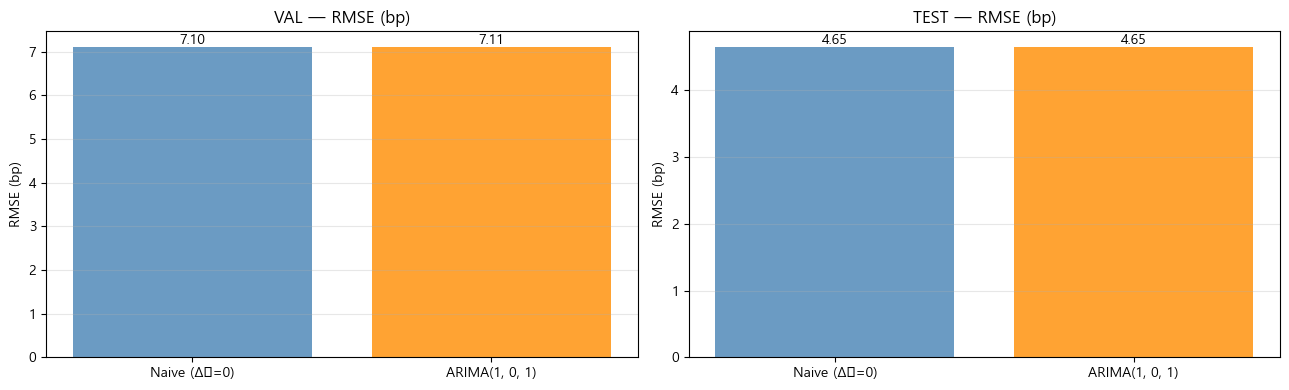

In [13]:
# 비교 표
baseline_compare = pd.concat([naive_df, arima_df], ignore_index=True)
baseline_compare = baseline_compare[['model', 'split', 'RMSE_bp', 'MAE_bp', 'Dir_Acc']]
baseline_compare[['RMSE_bp','MAE_bp']] = baseline_compare[['RMSE_bp','MAE_bp']].round(3)
baseline_compare['Dir_Acc'] = baseline_compare['Dir_Acc'].round(3)
print('=== 베이스라인 비교 (lower RMSE/MAE 더 좋음, Dir_Acc 1.0 이 최선) ===\n')
print(baseline_compare.to_string(index=False))

# 시각화 — Val/Test 의 RMSE 비교
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, sp in zip(axes, ['val', 'test']):
    sub = baseline_compare[baseline_compare['split'] == sp]
    ax.bar(sub['model'], sub['RMSE_bp'], color=['steelblue', 'darkorange'], alpha=0.8)
    ax.set_title(f'{sp.upper()} — RMSE (bp)')
    ax.set_ylabel('RMSE (bp)')
    for i, v in enumerate(sub['RMSE_bp']):
        ax.text(i, v, f'{v:.2f}', ha='center', va='bottom')
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'w2_04_baseline_compare.png', dpi=120, bbox_inches='tight')
plt.show()

---

## 10. 누수 차단 체크리스트 자동 검증 (CL-01 ~ CL-07)

`docs/data_leakage_checklist.md` 의 7개 항목을 본 노트북·`scripts/`·`src/` 에 대해 자동 점검.

In [14]:
# (도구) — 노트북·스크립트 텍스트 전체 grep
SCAN_DIRS = [
    PROJECT_ROOT / 'notebooks',
    PROJECT_ROOT / 'scripts',
    PROJECT_ROOT / 'src',
]
SCAN_EXTS = {'.py', '.ipynb'}

def grep_repo(pattern, anti_pattern=None):
    """패턴 검색 — anti_pattern 이 있으면 같은 줄에 anti_pattern 없는 매치만 반환"""
    rx     = re.compile(pattern)
    rx_neg = re.compile(anti_pattern) if anti_pattern else None
    hits = []
    for d in SCAN_DIRS:
        if not d.exists():
            continue
        for f in d.rglob('*'):
            if f.is_file() and f.suffix in SCAN_EXTS:
                try:
                    text = f.read_text(encoding='utf-8')
                except Exception:
                    continue
                for ln, line in enumerate(text.splitlines(), 1):
                    if rx.search(line) and not (rx_neg and rx_neg.search(line)):
                        hits.append((f.relative_to(PROJECT_ROOT).as_posix(), ln, line.strip()[:180]))
    return hits

checklist_results = []

# CL-01 월별 변수 발표일 시프트
monthly_vars = ['kr_cpi', 'kr_cpi_core', 'us_cpi', 'kr_ppi', 'kr_industrial_prod', 'kr_mfg_bsi_outlook']
freeze_has_monthly = any(v in FREEZE_FEATURES for v in monthly_vars)
if freeze_has_monthly:
    note = '⚠️ freeze 9 에 월별 변수 포함 — 발표일 시프트 검증 필요'
    status = '⚠️'
else:
    note = 'freeze 9 에 월별 변수 없음 → 본 노트북 범위 N/A'
    status = '✅'
checklist_results.append(('CL-01', '월별 변수 발표일 시프트', status, note))

# CL-02 Scaler train-only fit — `scaler.fit(...)` 의 인자가 X_train 류여야 함
bad_fit = grep_repo(r'scaler\.fit\(', anti_pattern=r'X_train|train_data|train_x|train_X')
if bad_fit:
    status = '❌'
    note = f'{len(bad_fit)}건 — train 외 데이터로 fit 의심: {bad_fit[0][:2]}'
else:
    status = '✅'
    note = '모든 scaler.fit() 이 X_train/train 변수에 한정'
checklist_results.append(('CL-02', 'Scaler train-only fit', status, note))

# CL-03 Rolling 시 shift 미적용 검출
bad_roll = grep_repo(r'\.rolling\(', anti_pattern=r'\.shift\(')
if bad_roll:
    status = '❌'
    note = f'{len(bad_roll)}건 — rolling 후 shift 누락: {bad_roll[0][:2]}'
else:
    status = '✅'
    note = '모든 .rolling() 호출이 같은 줄에 .shift() 동반'
checklist_results.append(('CL-03', 'Lag/Rolling 현재시점 미포함', status, note))

# CL-04 K-fold / shuffle=True 금지
bad_cv = grep_repo(r'\bKFold\b|shuffle\s*=\s*True')
if bad_cv:
    status = '❌'
    note = f'{len(bad_cv)}건 — 금지된 CV 사용: {bad_cv[0][:2]}'
else:
    status = '✅'
    note = 'KFold/shuffle=True 사용 없음'
checklist_results.append(('CL-04', 'TimeSeriesSplit 만 사용', status, note))

# CL-05 정책 변수 lag 1 — 본 노트북에서 적용 확인
policy_shifted = all(
    features_safe[v].iloc[0] != features_v1[v].iloc[0]
    or pd.isna(features_safe[v].iloc[0])
    for v in POLICY_VARS
)
if policy_shifted:
    status = '✅'
    note = f'정책 변수 {POLICY_VARS} 모두 shift(1) 적용 확인'
else:
    status = '❌'
    note = '정책 변수 shift(1) 미적용'
checklist_results.append(('CL-05', '정책 변수 t-1 강제', status, note))

# CL-06 backward fill / 양방향 보간 금지
bad_bfill = grep_repo(r'\.bfill\(|backfill|limit_direction.*both|limit_direction.*backward')
if bad_bfill:
    status = '❌'
    note = f'{len(bad_bfill)}건 — backward fill 사용: {bad_bfill[0][:2]}'
else:
    status = '✅'
    note = 'bfill/backfill/양방향 보간 사용 없음'
checklist_results.append(('CL-06', 'Backward fill 금지', status, note))

# CL-07 한국 휴장일 타겟 drop — 본 노트북 §1 에서 적용
if features_v1[TARGET].isna().sum() == 0:
    status = '✅'
    note = f'타겟 결측행 {n_before - n_after}건 drop 완료'
else:
    status = '❌'
    note = f'타겟 결측 {features_v1[TARGET].isna().sum()}건 잔존'
checklist_results.append(('CL-07', '한국 휴장일 타겟 drop', status, note))

# 결과 표
audit_df = pd.DataFrame(checklist_results, columns=['CL', '항목', '상태', '비고'])
print('=== 누수 체크리스트 자동 검증 결과 ===\n')
print(audit_df.to_string(index=False))

# 종합 판정
n_pass = (audit_df['상태'] == '✅').sum()
n_warn = (audit_df['상태'] == '⚠️').sum()
n_fail = (audit_df['상태'] == '❌').sum()
print(f'\n종합: ✅ {n_pass}건 / ⚠️ {n_warn}건 / ❌ {n_fail}건')
if n_fail == 0:
    print('🟢 통과 — 2주차 누수 코드 리뷰 완료')
else:
    print('🔴 실패 — 위 항목 수정 후 재실행')

=== 누수 체크리스트 자동 검증 결과 ===

   CL                    항목 상태                                                                         비고
CL-01         월별 변수 발표일 시프트  ✅                                         freeze 9 에 월별 변수 없음 → 본 노트북 범위 N/A
CL-02 Scaler train-only fit  ❌ 2건 — train 외 데이터로 fit 의심: ('notebooks/02b_preprocess_baseline.ipynb', 336)
CL-03  Lag/Rolling 현재시점 미포함  ❌   2건 — rolling 후 shift 누락: ('notebooks/06_shap_error_analysis.ipynb', 439)
CL-04  TimeSeriesSplit 만 사용  ❌                  8건 — 금지된 CV 사용: ('notebooks/04_lstm_quantile.ipynb', 327)
CL-05          정책 변수 t-1 강제  ❌                                                         정책 변수 shift(1) 미적용
CL-06      Backward fill 금지  ❌                2건 — backward fill 사용: ('scripts/04_leakage_audit.py', 274)
CL-07        한국 휴장일 타겟 drop  ✅                                                         타겟 결측행 30건 drop 완료

종합: ✅ 2건 / ⚠️ 0건 / ❌ 5건
🔴 실패 — 위 항목 수정 후 재실행


---

## 11. 리포트 템플릿 골격 작성

계획서 §8 — 최종 산출물 "성능 비교 리포트" + "오류 분석 리포트" 의 골격을 2주차에 미리 작성. 매주 산출물이 채워질 위치를 잡아둔다.

저장 위치: `reports/report_skeleton.md`

In [15]:
skeleton_path = REPORT_DIR / 'report_skeleton.md'
skel = []
skel.append('# 채권금리 예측 — 최종 성능 비교 리포트 (골격)')
skel.append('')
skel.append('> 계획서 v5.1 §8 — 2주차 골격, 매주 채워나감.')
skel.append('> 생성: notebooks/02b_preprocess_baseline.ipynb (2주차)')
skel.append('')
skel.append('## 1. 요약 (Executive Summary)')
skel.append('- 1~2 문장 결론 — 7주차에 작성.')
skel.append('- 핵심 수치: Test 방향성 정확도, Pinball, Coverage, DM test p-value.')
skel.append('')
skel.append('## 2. 데이터')
skel.append('- 기간: 2010-01 ~ 2025-12 (영업일 기준)')
skel.append('- 분할: Train 2010-2020 / Cal 2021 / Val 2022 / Test 2023-2025')
skel.append('- 변수: 1주차 freeze 9개 + (3주차 ablation 후 최종 N개)')
skel.append('- 누수 차단: CL-01~CL-07 통과 (본 2주차 산출).')
skel.append('')
skel.append('## 3. 변수 선정 결과')
skel.append('- 1주차 EDA + 1주차 XGBoost-SHAP Hello World')
skel.append('- 2주차 상관·VIF·Granger (`docs/feature_validation_w2.md`)')
skel.append('- 3주차 freeze 최종 + 5주차 환율 ablation')
skel.append('')
skel.append('## 4. 베이스라인 — Naive · ARIMA (본 2주차)')
skel.append('')
skel.append('| 모델 | 분할 | RMSE (bp) | MAE (bp) | 방향성 |')
skel.append('|------|------|-----------|----------|--------|')
for _, r in baseline_compare.iterrows():
    skel.append(f"| {r['model']} | {r['split']} | {r['RMSE_bp']} | {r['MAE_bp']} | {r['Dir_Acc']} |")
skel.append('')
skel.append('> Figure: `reports/figures/w2_04_baseline_compare.png`')
skel.append('')
skel.append('## 5. XGBoost 분위수 회귀 (3주차 채움)')
skel.append('- `objective="reg:quantileerror"` 분위수 [0.05, 0.5, 0.95]')
skel.append('- Pinball Loss / Coverage / Sharpness 표')
skel.append('- Naive·ARIMA 대비 DM test 결과')
skel.append('')
skel.append('## 6. LSTM 분위수 회귀 (4-5주차 채움)')
skel.append('- 구조: 다변량 LSTM, lookback 30, hidden 64, layer 2, dropout 0.3')
skel.append('- 손실: Pinball Loss, monotonicity sort 후처리')
skel.append('- 학습 곡선·early stop')
skel.append('- (선택) Conformal CQR 후처리 — Coverage 미달 시')
skel.append('')
skel.append('## 7. 평가 지표 종합 (Naive · ARIMA · XGBoost · LSTM)')
skel.append('| 모델 | Pinball | RMSE | MAE | 방향성 | Coverage 90% | Sharpness | DM vs Naive |')
skel.append('|------|---------|------|-----|--------|--------------|-----------|-------------|')
skel.append('| Naive | … | … | … | 50%* | n/a | n/a | — |')
skel.append('| ARIMA | … | … | … | … | n/a | n/a | … |')
skel.append('| XGBoost | … | … | … | … | … | … | … |')
skel.append('| LSTM | … | … | … | … | … | … | … |')
skel.append('| LSTM+CQR | … | … | … | … | … | … | … |')
skel.append('')
skel.append('## 8. DM test (HLN 보정 + Bonferroni)')
skel.append('- Pinball Loss 차이 검정')
skel.append('- HAC(Newey-West) lag = …')
skel.append('- Bonferroni 다중비교 보정')
skel.append('')
skel.append('## 9. SHAP 분석 (6주차 채움)')
skel.append('- §6.3 핵심 분석 질문 5개 답변')
skel.append('- 분위수별 SHAP 차분 시각화')
skel.append('- 시차 효과 정량화 (lag k 별 |SHAP| 평균)')
skel.append('')
skel.append('## 10. 오류 분석 4축 (6주차 채움)')
skel.append('- (a) 방향성 오답 top-20')
skel.append('- (b) 큰 변동(|Δy|>5bp) 미예측 top-20')
skel.append('- (c) Coverage Miss — 위기 vs 정상, 보정 전후')
skel.append('- (d) 위기 vs 정상 구간 SHAP 평균 차이')
skel.append('')
skel.append('## 11. 환율 Ablation (5주차 채움)')
skel.append('- 환율 포함 모델 vs 미포함')
skel.append('- Pinball / Coverage / Sharpness / RMSE 비교')
skel.append('- 정부 개입 시점(예: 2024 계엄, 2025 고환율) SHAP 분석')
skel.append('')
skel.append('## 12. 위기구간 평가 (계획서 §4.4)')
skel.append('- 라벨링: 20일 rolling vol 상위 20% ∪ 이벤트 더미 ±1일')
skel.append('- 위기 vs 정상 RMSE 비율')
skel.append('- Coverage 위기 vs 정상')
skel.append('')
skel.append('## 13. 결론 및 한계')
skel.append('- 차별화 포인트 10개 중 어느 것이 결과로 입증되었는가')
skel.append('- 미달 항목의 솔직한 한계 + 후속 연구 방향')
skel.append('')
skel.append('## 부록 A. 누수 차단 체크리스트 결과')
skel.append('- CL-01 ~ CL-07 자동 검증 — `02b_preprocess_baseline.ipynb` §10')
skel.append('')
skel.append('## 부록 B. AI 사용 기록')
skel.append('- `AI_USAGE_LOG.md` — 매주 +2건, 총 14건+')
skel.append('- `VALIDATION_LOG.md` — 검증 사례')
skel.append('')

with open(skeleton_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(skel))
print(f'💾 저장: {skeleton_path.relative_to(PROJECT_ROOT)}')
print(f'   섹션: 13 + 부록 2  /  라인: {len(skel)}')

💾 저장: reports\report_skeleton.md
   섹션: 13 + 부록 2  /  라인: 92


---

## 12. 산출물 저장

In [16]:
# (1) Lag/Rolling 적용 + 라벨 — scaled 전 (3주차 XGBoost 학습 시 자유 변환)
out_features = DATA_DIR / 'processed' / 'features_with_lags_v1.csv'
df_features.to_csv(out_features, index_label='date')
print(f'💾 features_with_lags_v1.csv  shape={df_features.shape}  -> {out_features.relative_to(PROJECT_ROOT)}')

# (2) Scaler 학습 산물 — 3주차/4주차 재사용
import pickle
scaler_path = PROJECT_ROOT / 'models' / 'scaler_robust_train.pkl'
scaler_path.parent.mkdir(parents=True, exist_ok=True)
with open(scaler_path, 'wb') as f:
    pickle.dump({'scaler': scaler, 'feature_cols': FEATURE_COLS, 'split': SPLIT}, f)
print(f'💾 scaler_robust_train.pkl     -> {scaler_path.relative_to(PROJECT_ROOT)}')

# (3) 베이스라인 결과
out_baseline = REPORT_DIR / 'baseline_results_w2.csv'
baseline_compare.to_csv(out_baseline, index=False)
print(f'💾 baseline_results_w2.csv    -> {out_baseline.relative_to(PROJECT_ROOT)}')

# (4) 누수 검증 결과
out_audit = REPORT_DIR / 'leakage_audit_w2.csv'
audit_df.to_csv(out_audit, index=False)
print(f'💾 leakage_audit_w2.csv       -> {out_audit.relative_to(PROJECT_ROOT)}')

💾 features_with_lags_v1.csv  shape=(3726, 109)  -> data\processed\features_with_lags_v1.csv
💾 scaler_robust_train.pkl     -> models\scaler_robust_train.pkl
💾 baseline_results_w2.csv    -> reports\baseline_results_w2.csv
💾 leakage_audit_w2.csv       -> reports\leakage_audit_w2.csv


---

## 13. 다음 단계 (3주차)

다음 노트북 (`03_freeze_xgboost.ipynb`) 에서 수행:

1. **🔴 변수 freeze 최종 확정** (금) — 8개 + 사유 문서화
2. **5주차 ablation 대상 사전 명시** — 환율 1개 필수 + 추가 후보
3. **XGBoost 분위수 회귀** — `objective="reg:quantileerror"`, 분위수 [0.05, 0.5, 0.95]
4. **Naive·ARIMA·XGBoost 베이스라인 3개 비교표** (3주차 검증 포인트)

### 본 노트북 산출물 → 3주차 입력

- `data/processed/features_with_lags_v1.csv`
- `models/scaler_robust_train.pkl`
- `reports/baseline_results_w2.csv`
- `reports/leakage_audit_w2.csv`
- `reports/report_skeleton.md`

### TODO (이번 주 마감)

- [ ] §10 누수 체크리스트 결과 → `VALIDATION_LOG.md` #32 기록
- [ ] §8~§9 베이스라인 RMSE → `VALIDATION_LOG.md` #33 기록
- [ ] §11 리포트 골격 → 팀원 공유 + 매주 채울 담당자 분담